## Keras: A high level neural network library

In this exercise we will revisit classification using simple neural networks. To do so we will use Keras, a popular neural network package. Keras is a high level library that allows rapid prototyping of neural networks due to its precompiled layers, just as Scikit-learn contains a number of prebuilt classifiers.


## Keras

Detailed instructions can be found at https://keras.io.


# Exercise 1

### Convolution Neural Netwrok

In neural networks, Convolutional neural network (ConvNets or CNNs) is one of the main categories to do images recognition, images classifications. Objects detections, recognition faces etc., are some of the areas where CNNs are widely used.

CNN models to train and test, each input image will pass it through a series of convolution layers with filters (Kernals), Pooling, fully connected layers (FC) and apply Softmax function to classify an object with probabilistic values between 0 and 1.

The dataset which we will use in this part is MNIST classification dataset. This is a dataset of 28x28 pixel grayscale images of items of 10 digits from 0 to 9.



In [1]:
from keras.models import Sequential
from keras.datasets import mnist
from keras.layers import Conv2D, MaxPool2D
from keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical


(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
print(x_train.shape)

(60000, 28, 28)


Create a plot of the first nine images in the training dataset.

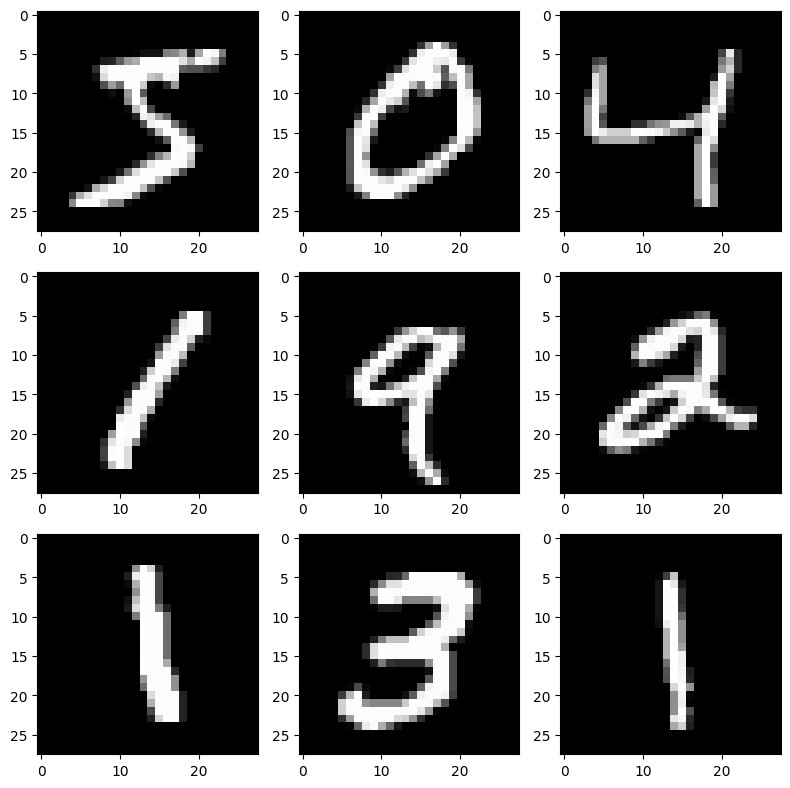

In [3]:
import matplotlib.pyplot as plt
# plot first few images
plt.figure(figsize=(8, 8))
for idx in range(9):
    plt.subplot(3, 3, idx + 1)
    plt.imshow(x_train[idx], cmap='gray')
plt.tight_layout()
plt.show()

Q1. To process images in neural network, we have to indicate how may channels (depth) we are going to use. For instance, a coloful image from a standard digital camera will have a red, green and blue channel (RGB), so it has 3 channels (i.e. depth=3) in total, whereas a grayscale image only has 1 channel (depth=1).

The Fashion-MNIST dataset is grayscale, and we can reshape Fashion-MNIST to have a single channel. (i.e., Convert each 28 x 28 image of the train and test set into a matrix of size 28 x 28 x 1.)

In [4]:
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

We know that the pixel values for each image in the dataset are unsigned integers in the range between black and white, or 0 and 255.

Q2. Normalize the pixel values of grayscale images, e.g. rescale them to the range [0, 1].

In [5]:
### YOUR CODE HERE ###
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

Q3. You also need to convert the target values into binary values (one-hot encoding).

In [6]:
### YOUR CODE HERE ###
y_train_final = to_categorical(y_train, num_classes=10)
y_test_final = to_categorical(y_test, num_classes=10)

In [7]:
# Display the change for category label using one-hot encoding
print('Original label:', y_train[0])
print('One-hot encoded label:', y_train_final[0])

Original label: 5
One-hot encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Q4. Implement build_cnn_model() that returns a CNN model that takes an input of image, passes it to:
- A convolution layer with 32 filters and filter/kernel size 5x5
- A MaxPool layer of size 2x2
- Another convolution layer with 64 filters and kernel size 5x5
- Another MaxPool layer of size 2x2
- Another convolution layer with 128 filters and kernel size 3x3
- Another MaxPool layer of size 2x2
- Flatten it
- Add one regular fully-connected layer of 128 units
- Finally, output your classification by another fully-connected layer, whose number of units is determined by yourself.

Our goal is to minimize the entropy loss.

As before, use the "relu" activation function for all the convolution/full-connected layers, but use the "softmax" activation for the final fully-connected layer (readout layer).

The optimizer and loss function have been filled in for you.

https://www.tensorflow.org/tutorials/images/cnn:

As input, a CNN takes tensors of shape (image_height, image_width, color_channels), ignoring the batch size. If you are new to these dimensions, color_channels refers to (R,G,B).

the output of every Conv2D and MaxPooling2D layer is a 3D tensor of shape (height, width, channels/depth). The width and height dimensions tend to shrink as you go deeper in the network. The number of output channels/depth for each Conv2D layer is controlled by the first argument (e.g., 32 or 64). Typically, as the width and height shrink, you can afford (computationally) to add more output channels in each Conv2D layer.

(See https://towardsdatascience.com/applied-deep-learning-part-4-convolutional-neural-networks-584bc134c1e2)

Pooling: After a convolution operation we usually perform pooling to reduce the dimensionality. This enables us to reduce the number of parameters, which both shortens the training time and combats overfitting. Pooling layers downsample each feature map independently, reducing the height and width, keeping the depth intact.

Padding: is commonly used in CNN to preserve the size of the feature maps, otherwise they would shrink at each layer, which is not desirable. The 3D convolution figures we saw above used padding, that’s why the height and width of the feature map.

To complete the model, you will feed the last output tensor from the convolutional base (of shape (4, 4, 64)) into one or more Dense layers to perform classification. Dense layers take vectors as input (which are 1D), while the current output is a 3D tensor. First, you will **flatten** (or unroll) the 3D output to 1D, then add one or more Dense layers on top. The data 10 output classes, so you use a final Dense layer with 10 outputs.

In [8]:
def build_cnn_model():
    model = Sequential()
    model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPool2D((2, 2)))
    model.add(Conv2D(64, (5, 5), activation='relu'))
    model.add(MaxPool2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPool2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
    return model

model = build_cnn_model()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 24, 24, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 8, 8, 64)            │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 2, 2, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 143,754 (561.54 KB)

 Trainable params: 143,754 (561.54 KB)

 Non-trainable params: 0 (0.00 B)

Q5. Fit your model by x_train, y_train

In [10]:
model.fit(x_train, y_train_final, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8442 - loss: 0.5016 - val_accuracy: 0.9780 - val_loss: 0.0743
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0580 - val_accuracy: 0.9866 - val_loss: 0.0459
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9891 - loss: 0.0339 - val_accuracy: 0.9902 - val_loss: 0.0349
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9926 - loss: 0.0249 - val_accuracy: 0.9888 - val_loss: 0.0415
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9935 - loss: 0.0190 - val_accuracy: 0.9830 - val_loss: 0.0606
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9940 - loss: 0.0179 - val_accuracy: 0.9886 - val_loss: 0.0416
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9950 - loss: 0.0152 - val_accuracy: 0.9892 - val_loss: 0.0393
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.

Q6. Evaluate your model on test set and print out the entropy loss and the accuracy

In [11]:
cnn_test_loss, cnn_test_accuracy = model.evaluate(x_test, y_test_final)
print(f"Test Loss: {cnn_test_loss}")
print(f"Test Accuracy: {cnn_test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9910 - loss: 0.0326
Test Loss: 0.028556689620018005
Test Accuracy: 0.9923999905586243


Q7. Now let's check the performance of multi-layer perceptrons (MLP) in image classfication. Implement build_mlp_model() that returns a MLP model that takes an input of image, passes it to 1 Flatten layer then 3 full-connected layers and the final fully-connected readout layer.

The number of units in each full-connected layer is determined by yourself.

As before, use the "relu" activation function for the first 2 full-connected layers, but use the "softmax" activation for the final fully-connected layer (readout layer).

The optimizer and loss function have been filled in for you.

In [12]:
def build_mlp_model():
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
    return model
model2 = build_mlp_model()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Q8. Fit your MLP model by x_train, y_train. (Please use the same parameters with those in CNN model for comparison)

In [13]:
model2.fit(x_train, y_train_final, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8331 - loss: 0.5674 - val_accuracy: 0.9538 - val_loss: 0.1598
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9603 - loss: 0.1350 - val_accuracy: 0.9687 - val_loss: 0.1079
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9761 - loss: 0.0831 - val_accuracy: 0.9719 - val_loss: 0.0961
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9803 - loss: 0.0618 - val_accuracy: 0.9716 - val_loss: 0.0925
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9859 - loss: 0.0469 - val_accuracy: 0.9737 - val_loss: 0.0924
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9894 - loss: 0.0375 - val_accuracy: 0.9727 - val_loss: 0.0937
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9903 - loss: 0.0309 - val_accuracy: 0.9747 - val_loss: 0.0942
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9920 - loss: 0.0251 - val_accuracy: 0.

Q9. Evaluate your model on test set and print out the entropy loss and the accuracy

In [14]:
mlp_test_loss, mlp_test_accuracy = model2.evaluate(x_test, y_test_final)
print(f"MLP Test Loss: {mlp_test_loss}")
print(f"MLP Test Accuracy: {mlp_test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9711 - loss: 0.1206
MLP Test Loss: 0.10810196399688721
MLP Test Accuracy: 0.9746999740600586


Q10. Which of the above 2 models worked best for you? Explain in details the reason for good/bad performance for each of the models.

Ans - The CNN model outperformed the MLP model in terms of both accuracy and loss, making it the better choice for this task.  This superior performance is attributed to the CNN’s architecture, which is specifically designed for image-related tasks. By using convolutional layers, the CNN effectively detects spatial features such as edges, shapes, and textures, while pooling layers reduce dimensionality and enhance generalization. In contrast, the MLP flattens image data, losing spatial information critical for recognizing patterns in images. Although simpler and faster to train, the MLP’s dense structure lacks the spatial awareness and hierarchical feature extraction capabilities that make CNNs ideal for image classification tasks. As a result, the CNN demonstrated greater confidence and accuracy, solidifying its position as the better-performing model for the MNIST dataset.

# Exercise 2
### Autoencoder

So far, we have learned a lot about how to use neural networks in supervised learning, but in fact there are also many applications of neural networks in unsupervised learning such as autoencoder.

An autoencoder is a special type of neural network that is trained to copy its input to its output. For example, given an image of a handwritten digit, an autoencoder first encodes the image into a lower dimensional latent representation, then decodes the latent representation back to an image. An autoencoder learns to compress the data while minimizing the reconstruction error.

In this part, we will continue using Fashion-MNIST dataset.

Q11. Implement an autoencoder model that takes an input of 28x28x1 images, compress them into (4,) vectors by an econder, and then decompress them back to 28x28 images by a decoder. In other words, the orginal dimensionality is 784 (=28x28), but we want to compress it into the dimensionality of 9 by an encoder, then reconstruct these (9,) vectors back to 28x28 images by an decoder.

You only need to define an encoder and a decoder. In your encoder, you need to inlude a flatten layer and several fully-connected layers, while in your decoder, you are required to use fully-connected layers and one reshape layer. Do not use other types of layers.

You will determine the number of fully-connected layers, number of units, and activation functions by yourself.

The optimizer and loss function have been filled in for you.

In [15]:
from keras.models import Model
from keras.layers import Reshape, Input
# encoder layers
encoding_dim = 9
encoded = Sequential()
img_x = 28
img_y = 28
encoded.add(Flatten(input_shape=(img_x, img_y, 1)))
encoded.add(Dense(128, activation='relu'))
encoded.add(Dense(64, activation='relu'))
encoded.add(Dense(encoding_dim, activation='relu'))
# decoder layers
decoded = Sequential()
decoded.add(Dense(64, activation='relu', input_shape=(encoding_dim,)))
decoded.add(Dense(128, activation='relu'))
decoded.add(Dense(img_x * img_y, activation='sigmoid'))
decoded.add(Reshape((img_x, img_y, 1)))

input_x = Input(shape=(img_x, img_y, 1))
code = encoded(input_x)
output = decoded(code)

# This model maps an input to its reconstruction
autoencoder = Model(input_x,output)

autoencoder.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Q12. Fit your model by x_train only

In [16]:
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.1082 - val_loss: 0.0464
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0418 - val_loss: 0.0330
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0315 - val_loss: 0.0284
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0279 - val_loss: 0.0268
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0264 - val_loss: 0.0256
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0253 - val_loss: 0.0247
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0243 - val_loss: 0.0241
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0237 - val_loss: 0.0235
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0231 - val_loss: 0.0229
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0226 - val_loss: 0.0225
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0221 - val_loss: 0.0221
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

Q13. Evaluate your model on test set and print out the MSE and output images as numpy arrays.

In [17]:
# Test your autoencoder on test set, print out the MSE
model_MSE = autoencoder.evaluate(x_test, x_test)
print(f"Model MSE: {model_MSE}")
# output images as numpy arrays
encoded_imgs = encoded(x_test).numpy()
decoded_imgs = decoded(encoded_imgs).numpy()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0176
Model MSE: 0.01723095402121544


Plot your encoded image

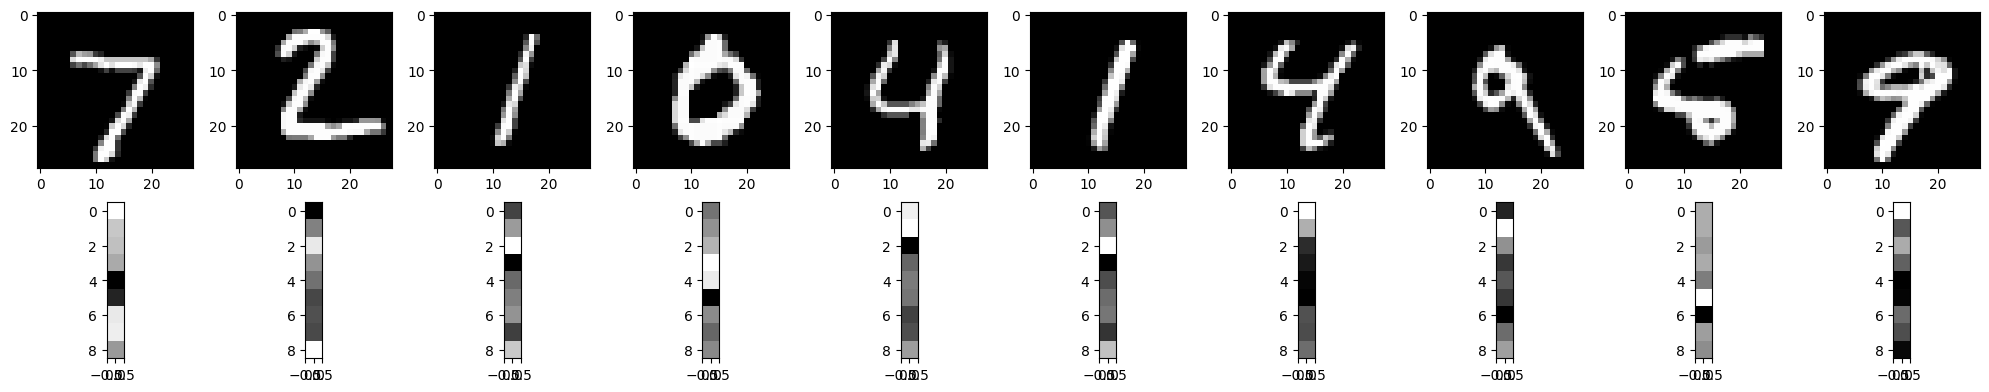

In [18]:
n = 10
fig = plt.figure(figsize=(20, 4))
for i in range(n):
  ax = fig.add_subplot(2, n, i+1)
  ax.imshow(x_test[i].reshape(28,28),cmap="gray")
  ax = fig.add_subplot(2, n, i+1+n)
  ax.imshow(encoded_imgs[i].reshape(encoding_dim, 1),cmap="gray")
plt.tight_layout()
plt.show()

Plot your decoded image

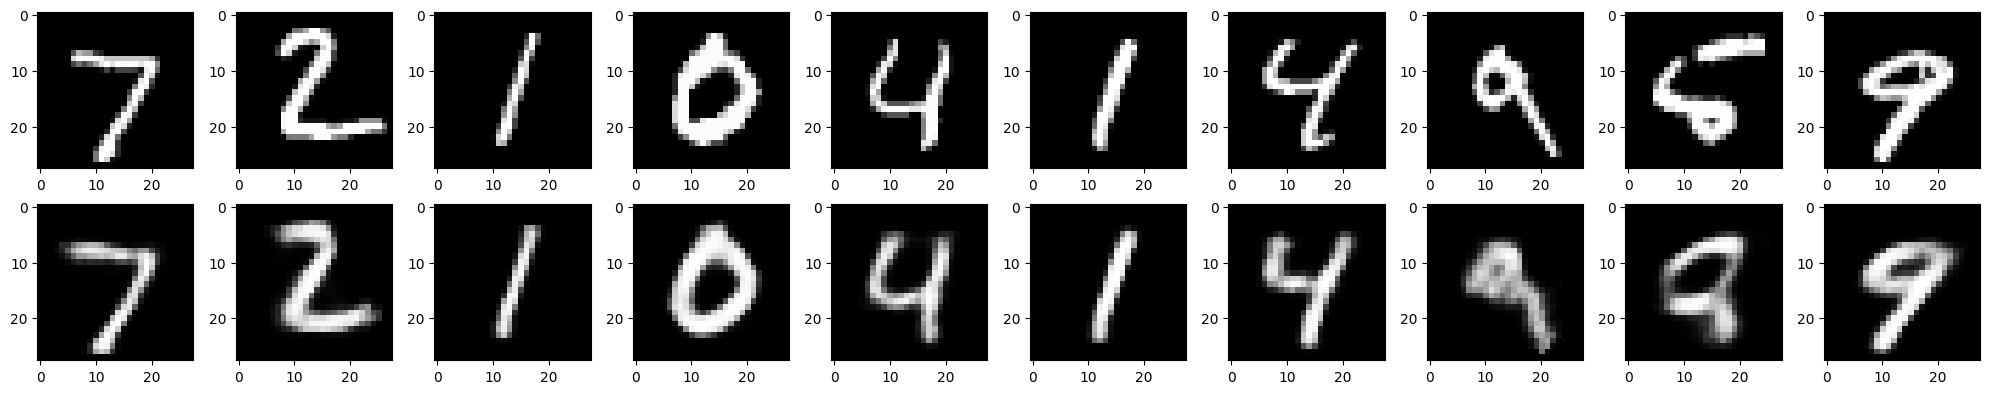

In [19]:
n = 10
fig1 = plt.figure(figsize=(20, 4))
for i in range(n):
  ax = fig1.add_subplot(2, n, i+1)
  ax.imshow(x_test[i].reshape(28,28),cmap="gray")
  ax = fig1.add_subplot(2, n, i+1+n)
  ax.imshow(decoded_imgs[i].reshape(28,28),cmap="gray")
plt.tight_layout()
plt.show()